In [9]:
import pandas as pd

# CSV 파일 경로
file_path = "C:/Users/USER/Desktop/SeSAC_DE/sesac_workspace/AbandonedAnimalsProject/data/abandoned_animals_2025.csv"
df = pd.read_csv(file_path)

# 데이터 확인
print(df.head())
print(df.info())


       desertionNo    happenDt       happenPlace upKindNm  kindNm  \
0  448545202500390  2025-12-03   산청군 단성면 목화로 966        개     믹스견   
1  448545202500389  2025-12-03   산청군신안면 신안리 87-4        개     믹스견   
2  448545202500388  2025-12-03    산청군 신등면 가회로 52        개     믹스견   
3  448541202501873  2025-12-03          창녕읍 남창녕로      고양이  한국 고양이   
4  447511202501450  2025-12-03  상주시 청리면 마공공단로 일대        개     믹스견   

               age     weight sexCd neuterYn processState      careNm  \
0         2009(년생)    2.2(Kg)     F        N          보호중    산청동물보호센터   
1         2021(년생)   13.5(Kg)     M        N          보호중    산청동물보호센터   
2         2018(년생)    5.3(Kg)     F        N          보호중    산청동물보호센터   
3  2025(60일미만)(년생)      1(Kg)     M        N          보호중  창녕 유기동물보호소   
4         2022(년생)  17.48(Kg)     M        N          보호중  상주시 동물보호센터   

      orgNm endReason age_group province  
0  경상남도 산청군       NaN      2009     경상남도  
1  경상남도 산청군       NaN      2021     경상남도  
2  경상남도 산청군      

desertionNo – 유기동물 번호, 각 동물에게 부여된 고유 ID  
happenDt – 유기 동물 발생일(YYYYMMDD 형식)  
happenPlace – 유기 동물이 발견된 장소 주소  
upKindNm – 상위 동물 이름 (대분류, 예: 개, 고양이 등)  
kindNm – 동물 품종 이름 (예: 믹스견, 시츄 등)  
age – 동물 나이 (예: 2개월, 3세)  
weight – 동물 몸무게 (kg 단위)  
sexCd – 성별 코드 (M=수컷, F=암컷)  
neuterYn – 중성화 여부 (Y=중성화, N=미중성화)  
processState – 처리 상태 (예: 보호중, 입양, 안락사 등)  
careNm – 보호센터 이름  
orgNm – 보호센터 소속 기관 이름 (시/군/구 단위)  
endReason – 보호 종료 사유 (예: 입양, 안락사, 강한 공격성 등)  

In [10]:
# ============================================
# 1. 나이(age) 값을 출산 판단에 맞게 표준화하는 함수
# ============================================
def normalize_age(age_str):
    """
    age 컬럼에 들어오는 문자열을 비교 가능한 형태로 변환하는 함수.
    
    예시 입력:
        "2025(60일미만)(년생)"
        "2025(년생)"
        "60일미만"

    처리 목적:
    - '60일미만'이면 아기(baby)로 분류 → 출산 그룹 가능성이 높음
    - '2025(년생)'은 '2025'만 남겨서 같은 출생년도끼리 묶기 쉽게 함
    """

    if pd.isna(age_str):
        return None

    # 1) 60일 미만 → 아주 어린 개체이므로 'baby'로 통일
    if "60일" in age_str:
        return "baby"

    # 2) "2025(년생)" → "2025"로 변환 (괄호 기준 앞부분)
    year = age_str.split("(")[0]
    if year.isdigit():
        return year

    # 3) 기타 예외적인 경우 그대로 반환
    return age_str


# ============================================
# 2. 기존 df에 age_group 컬럼 추가하여 표준화된 나이 정보 입력
# ============================================
df["age_group"] = df["age"].apply(normalize_age)


# ============================================
# 3. 출산 여부 판단 기준으로 사용할 컬럼 설정
#    (출산으로 추정되는 그룹은 이 컬럼들이 동일하게 나타난다)
# ============================================
group_cols = ["happenDt", "happenPlace", "upKindNm", "kindNm", "age_group"]


# ============================================
# 4. 위 조건으로 그룹핑하여 각 그룹의 개체 수 계산
# ============================================
group_counts = df.groupby(group_cols).size().reset_index(name="count")

# 5. 한 그룹에 3마리 이상이면 → 출산 그룹으로 판단
birth_groups = group_counts[group_counts["count"] >= 3]

print("출산으로 판단되는 그룹 수:", len(birth_groups))


# ============================================
# 6. 출산 그룹에 해당하는 행 데이터를 df에서 제거하는 과정
# ============================================

# birth_groups 와 df를 merge하여 ‘제거 대상’ 표시
df_merged = df.merge(
    birth_groups[group_cols], 
    on=group_cols, 
    how="left", 
    indicator=True
)

# _merge == 'left_only' 인 경우 = 출산 그룹이 아님 → 유지
df_clean = df_merged[df_merged["_merge"] == "left_only"].drop(columns=["_merge"])


# ============================================
# 7. 제거 전/후 데이터 개수 출력
# ============================================
print("제거 전 데이터 수:", len(df))
print("제거 후 데이터 수:", len(df_clean))
print("제거된 데이터 수:", len(df) - len(df_clean))


# ============================================
# 8. 최종 정제된 데이터프레임을 df로 갱신
# ============================================
df = df_clean


출산으로 판단되는 그룹 수: 0
제거 전 데이터 수: 64421
제거 후 데이터 수: 64421
제거된 데이터 수: 0


In [11]:
# ==============================
# 셀: 유기 동물 종류 및 품종 분석
# ==============================

# 1) 종류별 유기 동물 수 집계
kind_count = df['upKindNm'].value_counts()  # upKindNm 컬럼 기준으로 건수 세기
kind_count  # 집계 결과 확인


upKindNm
개      45836
고양이    17572
기타      1013
Name: count, dtype: int64

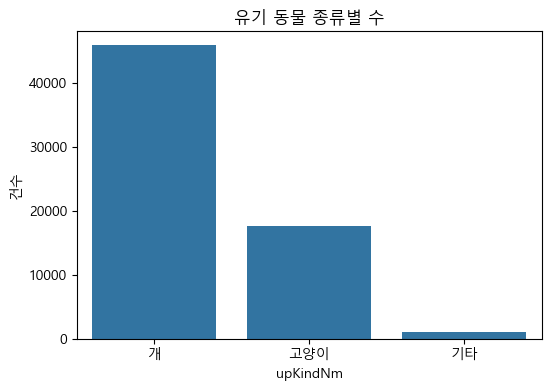

In [12]:
# 2) 종류별 막대그래프 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,4))  # 그래프 크기 설정
sns.barplot(x=kind_count.index, y=kind_count.values)  # x: 동물 종류, y: 건수
plt.title("유기 동물 종류별 수")  # 제목
plt.ylabel("건수")  # y축 레이블
plt.show()  # 그래프 출력


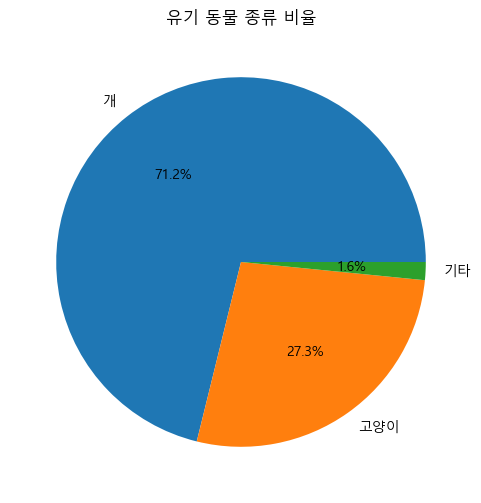

In [13]:
# 3) 종류별 파이차트 시각화
plt.figure(figsize=(6,6))  # 그래프 크기 설정
plt.pie(kind_count.values, labels=kind_count.index, autopct="%1.1f%%")  # 비율 표시
plt.title("유기 동물 종류 비율")  # 제목
plt.show()  # 그래프 출력


In [14]:
# 4) 품종별 유기 동물 수 상위 10개 집계
breed_count = df['kindNm'].value_counts().head(10)  # kindNm 기준으로 상위 10개
breed_count  # 집계 결과 확인


kindNm
믹스견       32687
한국 고양이    14177
푸들         2339
믹스묘        2230
말티즈        2044
포메라니안      1309
기타축종       1013
진도견         952
비숑 프리제      674
기타          450
Name: count, dtype: int64

In [15]:
print(df.shape)

(64421, 15)


In [16]:
# 시/도 컬럼
print(df['province'])

0           경상남도
1           경상남도
2           경상남도
3           경상남도
4           경상북도
          ...   
64416       경상북도
64417       경상북도
64418       경상북도
64419       경상북도
64420    전북특별자치도
Name: province, Length: 64421, dtype: object


In [17]:
# 중복 없이 province 값 확인
unique_provinces = df['province'].unique()
print(unique_provinces)


['경상남도' '경상북도' '전라남도' '전북특별자치도' '충청남도' '충청북도' '강원특별자치도' '경기도' '울산광역시'
 '광주광역시' '대구광역시' '제주특별자치도' '대전광역시' '인천광역시' '부산광역시' '서울특별시' '세종특별자치시']


In [18]:
# 각 province 값별 개수 확인
province_counts = df['province'].value_counts()
print(province_counts)


province
경기도        13088
경상북도        5531
전라남도        5383
경상남도        5200
전북특별자치도     5200
충청남도        4649
서울특별시       3398
인천광역시       3345
대구광역시       3207
부산광역시       3086
강원특별자치도     2763
충청북도        2741
제주특별자치도     2119
울산광역시       1727
광주광역시       1531
대전광역시       1151
세종특별자치시      302
Name: count, dtype: int64


In [20]:
# 시/도별 유기동물 수 집계
province_counts = df['province'].value_counts().reset_index()
province_counts.columns = ['province', 'count']
total_animals = len(df)
province_counts['percent'] = province_counts['count'] / total_animals * 100
print(province_counts)

# # 종별 개수 계산
# species_counts = df.pivot_table(
#     index='province',
#     columns='upKindNm',
#     aggfunc='size',
#     fill_value=0
# )
# province_counts = province_counts.merge(species_counts, on='province', how='left')

 # 마커 추가
for idx, row in province_counts.iterrows():
    print(row)

   province  count    percent
0       경기도  13088  20.316356
1      경상북도   5531   8.585710
2      전라남도   5383   8.355971
3      경상남도   5200   8.071902
4   전북특별자치도   5200   8.071902
5      충청남도   4649   7.216591
6     서울특별시   3398   5.274678
7     인천광역시   3345   5.192406
8     대구광역시   3207   4.978190
9     부산광역시   3086   4.790363
10  강원특별자치도   2763   4.288974
11     충청북도   2741   4.254824
12  제주특별자치도   2119   3.289300
13    울산광역시   1727   2.680803
14    광주광역시   1531   2.376554
15    대전광역시   1151   1.786684
16  세종특별자치시    302   0.468791
province          경기도
count           13088
percent     20.316356
Name: 0, dtype: object
province       경상북도
count          5531
percent     8.58571
Name: 1, dtype: object
province        전라남도
count           5383
percent     8.355971
Name: 2, dtype: object
province        경상남도
count           5200
percent     8.071902
Name: 3, dtype: object
province     전북특별자치도
count           5200
percent     8.071902
Name: 4, dtype: object
province        충청남도
count    

In [21]:
# 2. 종별 개수 계산 (피벗 테이블)
# df의 province와 upKindNm을 기준으로 각 province별 종 개수를 계산합니다.
species_counts = df.pivot_table(
    index='province',
    columns='upKindNm',
    aggfunc='size',
    fill_value=0
)
# 컬럼 이름이 '개', '고양이', '기타' 등으로 되어 있다고 가정합니다.

# 3. 데이터 병합
# total_counts에 종별 개수 데이터를 province를 기준으로 left join합니다.
# 이렇게 하면 province_counts에 있는 16개 행이 모두 유지됩니다.
province_counts = province_counts.merge(
    species_counts, 
    on='province', 
    how='left'
).fillna(0) # merge 후 혹시라도 없는 종 데이터는 0으로 채웁니다.

# province_counts의 dtype을 int로 변환 (count 및 종별 카운트)
cols_to_convert = ['count'] + list(species_counts.columns)
for col in cols_to_convert:
    if col in province_counts.columns:
            # 데이터가 float으로 변환되었을 수 있으므로 int로 변환
        province_counts[col] = province_counts[col].astype(int) 

# 🔑 핵심 수정 2: 지도 좌표 매칭의 안전성을 위해 'province' 이름 순서로 명시적 정렬
# 이 단계를 통해 'count'를 기준으로 한 초기 정렬(value_counts)이 해제됩니다.
province_counts = province_counts.sort_values(by='province').reset_index(drop=True)

In [22]:
print(province_counts)

   province  count    percent     개   고양이   기타
0   강원특별자치도   2763   4.288974  2230   517   16
1       경기도  13088  20.316356  9483  3320  285
2      경상남도   5200   8.071902  4433   738   29
3      경상북도   5531   8.585710  4804   689   38
4     광주광역시   1531   2.376554   789   728   14
5     대구광역시   3207   4.978190  1082  2074   51
6     대전광역시   1151   1.786684   778   338   35
7     부산광역시   3086   4.790363  1230  1790   66
8     서울특별시   3398   5.274678  1670  1535  193
9   세종특별자치시    302   0.468791   231    68    3
10    울산광역시   1727   2.680803   767   938   22
11    인천광역시   3345   5.192406  1870  1397   78
12     전라남도   5383   8.355971  4967   392   24
13  전북특별자치도   5200   8.071902  3721  1433   46
14  제주특별자치도   2119   3.289300  1700   407   12
15     충청남도   4649   7.216591  3958   646   45
16     충청북도   2741   4.254824  2123   562   56
